# BÁO CÁO PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU HÌNH ẢNH (IMAGE PREPROCESSING)

### Mô tả Tập dữ liệu (Dataset Description)
* **Tên bộ dữ liệu:** CIFAR-10 (Canadian Institute For Advanced Research)
* **Nguồn dữ liệu:** [Krizhevsky et al. - University of Toronto](https://www.cs.toronto.edu/~kriz/cifar.html)
* **Số lượng:** 60.000 ảnh màu (50.000 ảnh huấn luyện - Train set, 10.000 ảnh kiểm tra - Test set).
* **Kích thước gốc:** $32 \times 32$ pixels.
* **Kênh màu:** 3 kênh (RGB).
* **Phân lớp:** Gồm 10 lớp đối tượng khác nhau: *airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck*.
* **Mục đích sử dụng (Potential Use Cases):** Đây là bộ dữ liệu chuẩn (benchmark) dùng để đánh giá các thuật toán Học máy và Thị giác máy tính trong bài toán Phân loại hình ảnh (Image Classification) và Nhận dạng đối tượng (Object Recognition).

## A. LOADING AND RESIZING 

### A. Tải và Tiền xử lý dữ liệu CIFAR-10 (Loading & Preprocessing)

**Mục tiêu:**
Đoạn mã này thực hiện quy trình tải dữ liệu thô từ tệp nén, giải mã định dạng nhị phân một cách an toàn, khôi phục cấu trúc không gian (spatial dimensions) cho hình ảnh và phân tách rõ ràng tập Huấn luyện (Train) và tập Kiểm tra (Test) để phục vụ cho các bước phân tích tiếp theo.

**Chi tiết thực hiện (Implementation Details):**

1.  **Cấu hình và Giải nén tự động:**
    * Sử dụng thư viện `tarfile` để tự động giải nén file `cifar-10-python.tar.gz` nếu chưa được giải nén. Điều này đảm bảo tính tái lập (reproducibility) của dự án.
2.  **Đọc file an toàn (Robust Error Handling):**
    * Thay vì dùng hàm `pickle` cơ bản, nhóm xây dựng hàm `unpickle_safe` với cấu trúc `try-except` để bắt các lỗi phổ biến như không tìm thấy file (`FileNotFoundError`) hoặc file bị hỏng hóc, thiếu trường dữ liệu cốt lõi (`data`, `labels`).
3.  **Tải tập Train và Test riêng biệt (Data Separation):**
    * Trích xuất 50.000 ảnh từ 5 file `data_batch` cho tập Huấn luyện và 10.000 ảnh từ `test_batch` cho tập Kiểm tra. Việc tách biệt này từ sớm là quy chuẩn bắt buộc (best practice) để tránh rò rỉ dữ liệu (Data Leakage) khi tính toán các tham số chuẩn hóa sau này.
4.  **Khôi phục cấu trúc ảnh (Reshape & Transpose):**
    * Dữ liệu gốc được lưu dưới dạng vector phẳng.
    * **Reshape:** Định hình lại thành kích thước $(N, 3, 32, 32)$ tương ứng với cấu trúc **Channel-First** (Số lượng, Kênh màu, Chiều cao, Chiều rộng).
    * **Transpose:** Hoán đổi trục `(0, 2, 3, 1)` để chuyển về dạng **Channel-Last** $(N, 32, 32, 3)$. Đây là chuẩn bắt buộc đối với thư viện hiển thị (`matplotlib`) và OpenCV.
5.  **Xác thực dữ liệu (Data Validation):**
    * Áp dụng lệnh `assert` để đảm bảo dữ liệu giữ nguyên kiểu `uint8` và đúng kích thước ma trận trước khi đi vào các bước tốn kém tài nguyên hơn. Việc giữ nguyên `uint8` ở bước này giúp tiết kiệm tối đa RAM.

Dữ liệu không tồn tại. Đang tải từ: https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz...
Tải xuống hoàn tất: ../data/images/cifar-10-python.tar.gz
Đang giải nén file '../data/images/cifar-10-python.tar.gz'...
Giải nén thành công!

Danh sách các lớp: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Đang tải dữ liệu CIFAR-10...
-> Hoàn tất! Kích thước Train set: (50000, 32, 32, 3), Test set: (10000, 32, 32, 3)


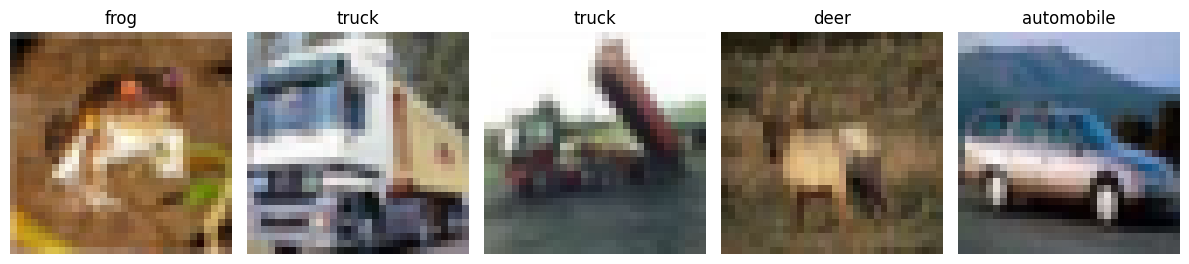

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import urllib.request
import tarfile 

# --- 1. CẤU HÌNH ĐƯỜNG DẪN & URL ---
# URL chính thức của CIFAR-10 từ ĐH Toronto
url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
compressed_file = '../data/images/cifar-10-python.tar.gz' 
extract_folder = '../data/images/'
data_path = os.path.join(extract_folder, 'cifar-10-batches-py')

os.makedirs(extract_folder, exist_ok=True)

# --- 2. TỰ ĐỘNG TẢI DỮ LIỆU (DOWNLOAD) ---
if not os.path.exists(compressed_file) and not os.path.exists(data_path):
    print(f"Dữ liệu không tồn tại. Đang tải từ: {url}...")
    try:
        urllib.request.urlretrieve(url, compressed_file)
        print(f"Tải xuống hoàn tất: {compressed_file}")
    except Exception as e:
        print(f"LỖI trong quá trình tải: {e}")
        exit()
else:
    print("Dữ liệu đã có sẵn (file nén hoặc thư mục giải nén), bỏ qua bước tải.")

# --- 3. GIẢI NÉN ---
if not os.path.exists(data_path):
    print(f"Đang giải nén file '{compressed_file}'...")
    try:
        with tarfile.open(compressed_file, 'r:gz') as tar:
            tar.extractall(path=extract_folder)
        print("Giải nén thành công!")    
    except Exception as e:
        print(f"LỖI khi giải nén: {e}")
else:
    print("Thư mục dữ liệu đã tồn tại, bỏ qua bước giải nén.")
# --- 4. HÀM ĐỌC FILE  ---
def unpickle_safe(file, required_keys=None):
    try:
        with open(file, 'rb') as fo:
            data = pickle.load(fo, encoding='bytes')
        if required_keys:
            for key in required_keys:
                if key not in data:
                    raise ValueError(f"File {file} thiếu key '{key}'")
        return data
    except FileNotFoundError:
        raise FileNotFoundError(f"LỖI: Không tìm thấy file {file}")
    except Exception as e:
        raise RuntimeError(f"LỖI khi đọc file {file}: {e}")

# --- 5. ĐỌC FILE META (LẤY TÊN NHÃN) ---
meta_file = os.path.join(data_path, 'batches.meta')
try:
    meta_data = unpickle_safe(meta_file, required_keys=[b'label_names'])
    label_names = [x.decode('utf-8') for x in meta_data[b'label_names']]
    print("\nDanh sách các lớp:", label_names)
except Exception as e:
    print(e)
    label_names = [f"Class_{i}" for i in range(10)]

# --- 6. TẢI TOÀN BỘ DỮ LIỆU TRAIN VÀ TEST ---
print("\nĐang tải dữ liệu CIFAR-10...")

all_train_images = []
all_train_labels = []

for i in range(1, 6):
    file_path = os.path.join(data_path, f'data_batch_{i}')
    batch = unpickle_safe(file_path, required_keys=[b'data', b'labels'])
    all_train_images.append(batch[b'data'])
    all_train_labels.append(batch[b'labels'])

raw_train_data = np.vstack(all_train_images)
raw_train_labels = np.hstack(all_train_labels)

test_batch = unpickle_safe(os.path.join(data_path, 'test_batch'), required_keys=[b'data', b'labels'])
raw_test_data = test_batch[b'data']
raw_test_labels = np.array(test_batch[b'labels'])

# --- 7. XỬ LÝ ẢNH (RESHAPE & TRANSPOSE) ---
train_images = raw_train_data.reshape(len(raw_train_data), 3, 32, 32).transpose(0, 2, 3, 1)
test_images = raw_test_data.reshape(len(raw_test_data), 3, 32, 32).transpose(0, 2, 3, 1)

# --- 8. KIỂM TRA TÍNH HỢP LỆ (DATA VALIDATION) ---
assert train_images.dtype == np.uint8, f"Dữ liệu phải là uint8, nhưng đang là {train_images.dtype}"
assert train_images.shape == (50000, 32, 32, 3), f"Sai kích thước tập Train: {train_images.shape}"
assert test_images.shape == (10000, 32, 32, 3), f"Sai kích thước tập Test: {test_images.shape}"

print(f"-> Hoàn tất! Kích thước Train set: {train_images.shape}, Test set: {test_images.shape}")

# --- 9. HIỂN THỊ KẾT QUẢ TRỰC QUAN ---
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i])
    label_id = raw_train_labels[i]
    plt.title(label_names[label_id])
    plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Thay đổi kích thước ảnh (Resizing)

**Mục tiêu & Lý do (Rationale):**
* **Mục tiêu:** Tăng kích thước không gian của ảnh từ $32 \times 32$ lên $128 \times 128$ pixel cho cả tập Train và tập Test.
* **Lý do chọn kích thước:** Mặc dù kích thước gốc giúp giảm chi phí tính toán, nhưng nó quá nhỏ để áp dụng các kiến trúc Deep Learning hiện đại (như VGG16, ResNet - thường yêu cầu đầu vào $\ge 224 \times 224$). Việc phóng to lên $128 \times 128$ là một sự đánh đổi hợp lý (trade-off) giữa việc giữ lại cấu trúc không gian đủ lớn cho các tầng tích chập (Convolution) và việc đảm bảo hiệu suất tính toán trên máy cá nhân.
* **Phương pháp:** Sử dụng thuật toán **Nội suy song tuyến tính (Bilinear Interpolation)**.

**Chi tiết thực hiện (Implementation Details):**
* Sử dụng thư viện `OpenCV` (`cv2.resize`) để xử lý.
* **Tham số `cv2.INTER_LINEAR`:** Đây là phương pháp nội suy mặc định cho việc phóng to ảnh (Upscaling). Thuật toán tính toán giá trị pixel mới dựa trên trung bình có trọng số của 4 pixel lân cận $(2 \times 2)$. Nó giúp làm mượt các cạnh, tránh hiện tượng vỡ hạt (pixelated) thường thấy khi dùng *Nearest Neighbor*.
* **Tối ưu hóa hiệu suất (Performance Optimization):** Thay vì dùng vòng lặp `for` tuần tự (sequential) tốn nhiều thời gian, nhóm áp dụng kỹ thuật **Xử lý song song đa luồng (Multiprocessing)** thông qua thư viện `concurrent.futures`. Việc này giúp tận dụng đa nhân CPU, giảm thiểu đáng kể thời gian tiền xử lý cho 60.000 bức ảnh.

Đang resize ảnh từ (32, 32) lên (128, 128)...
-> Đang xử lý tập Huấn luyện (Train)...
  > Hoàn thành 50000 ảnh trong 2.40 giây.
-> Đang xử lý tập Kiểm tra (Test)...
  > Hoàn thành 10000 ảnh trong 0.46 giây.

Kích thước sau khi resize:
- Train resized: (50000, 128, 128, 3)
- Test resized: (10000, 128, 128, 3)


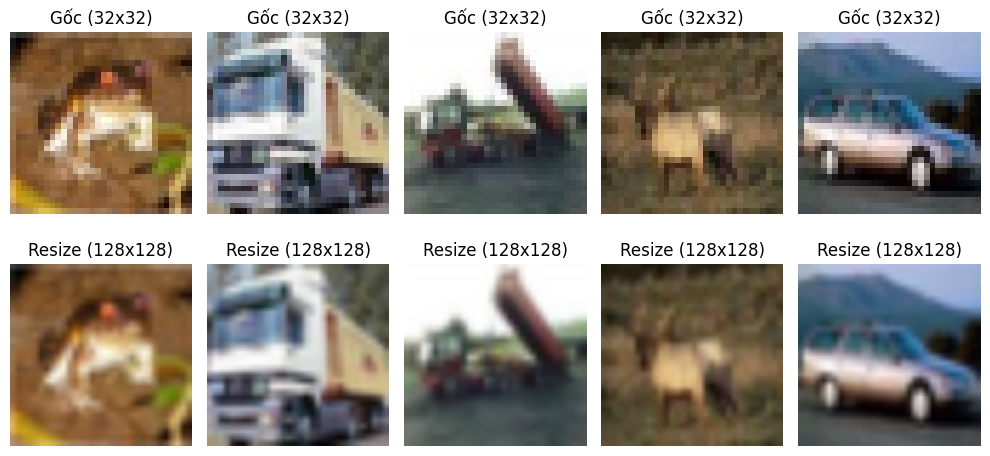

In [2]:
import cv2
import time
from concurrent.futures import ThreadPoolExecutor

# --- 1. CHỌN KÍCH THƯỚC MỤC TIÊU ---
TARGET_SIZE = (128, 128) 
print(f"Đang resize ảnh từ (32, 32) lên {TARGET_SIZE}...")

# --- 2. HÀM RESIZE ĐƠN ---
def resize_single_image(img):
    # Sử dụng INTER_LINEAR 
    return cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)

# --- 3. HÀM RESIZE HÀNG LOẠT (TỐI ƯU ĐA LUỒNG) ---
def resize_images_parallel(images_array):
    """Sử dụng ThreadPoolExecutor để xử lý song song giúp tăng tốc độ"""
    start_time = time.time()

    with ThreadPoolExecutor() as executor:
        resized_list = list(executor.map(resize_single_image, images_array))
        
    print(f"  > Hoàn thành {len(images_array)} ảnh trong {time.time() - start_time:.2f} giây.")
    return np.array(resized_list, dtype=np.uint8)

# --- 4. THỰC HIỆN RESIZE CHO TRAIN VÀ TEST ---
print("-> Đang xử lý tập Huấn luyện (Train)...")
train_images_resized = resize_images_parallel(train_images)

print("-> Đang xử lý tập Kiểm tra (Test)...")
test_images_resized = resize_images_parallel(test_images)

print(f"\nKích thước sau khi resize:")
print(f"- Train resized: {train_images_resized.shape}")
print(f"- Test resized: {test_images_resized.shape}")

# --- 5. HIỂN THỊ SO SÁNH TRỰC QUAN ---
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i])
    plt.title("Gốc (32x32)")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(train_images_resized[i])
    plt.title(f"Resize ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Phân tích Đánh đổi: Kích thước ảnh và Hiệu quả Tính toán (Computational Efficiency Trade-offs)

Việc thay đổi kích thước ảnh từ $32 \times 32$ lên $128 \times 128$ tạo ra sự đánh đổi rõ rệt giữa chất lượng mô hình và tài nguyên hệ thống. Nhóm phân tích sự đánh đổi này dựa trên 3 yếu tố cốt lõi:

**1. Độ phức tạp tính toán (Computational Complexity - FLOPs):**
* **Quy luật tăng trưởng:** Số lượng điểm ảnh tăng theo hàm bình phương của kích thước cạnh.
    * Ảnh gốc ($32 \times 32$): $32 \times 32 \times 3 = 3.072$ pixels.
    * Ảnh resize ($128 \times 128$): $128 \times 128 \times 3 = 49.152$ pixels.
    * $\rightarrow$ Số lượng dữ liệu đầu vào tăng gấp **16 lần**.
* **Hệ quả:** Số lượng phép tính số thực (FLOPs) trong các tầng tích chập (Convolutional Layers) đầu tiên sẽ tăng tương ứng khoảng 16 lần. Điều này dẫn đến thời gian huấn luyện (Training time) trên mỗi epoch sẽ kéo dài đáng kể.

**2. Bộ nhớ GPU/RAM (Memory Usage):**
* Kích thước ảnh lớn hơn đồng nghĩa với việc ma trận đầu vào (Input Tensor) chiếm nhiều bộ nhớ hơn. Khi tính tổng cho cả tập Train và Test (60.000 ảnh), dung lượng RAM yêu cầu tăng từ ~0.17 GB lên mức ~2.75 GB (ở định dạng `uint8`).
* **Đánh đổi:** Để tránh lỗi Out Of Memory (OOM) khi đưa vào GPU huấn luyện, chúng ta sẽ buộc phải **giảm Batch Size** (ví dụ: từ 128 xuống còn 32 hoặc 16). Việc này có thể làm nhiễu (noisy) quá trình cập nhật Gradient Descent.

**3. Kết luận về Hiệu quả:** Việc chọn kích thước $128 \times 128$ là một điểm cân bằng (Sweet spot) cho bài tập này. Nó cung cấp đủ không gian pixel để áp dụng các mô hình Deep Learning phổ biến mà không gây quá tải cho phần cứng cá nhân như mức $224 \times 224$ (tăng khối lượng tính toán lên ~50 lần).

In [3]:
import sys

num_images = train_images.shape[0] + test_images.shape[0] 

# 1. Tính dung lượng cho 1 ảnh (byte)
size_one_32 = 32 * 32 * 3 * 1       # 1 byte (uint8)
size_one_128 = 128 * 128 * 3 * 1    # 1 byte (uint8)

print(f"Dung lượng 1 ảnh 32x32  : {size_one_32 / 1024:.2f} KB")
print(f"Dung lượng 1 ảnh 128x128: {size_one_128 / 1024:.2f} KB")
print(f"-> Tăng gấp: {size_one_128 / size_one_32} lần")

# 2. Tính tổng dung lượng cho cả bộ dữ liệu (Train + Test)
total_size_32 = size_one_32 * num_images
total_size_128 = size_one_128 * num_images

print(f"\n--- TỔNG DUNG LƯỢNG RAM CHO {num_images:,} ẢNH (uint8) ---")
print(f"Ở kích thước 32x32  : {total_size_32 / (1024**3):.2f} GB")
print(f"Ở kích thước 128x128: {total_size_128 / (1024**3):.2f} GB")

Dung lượng 1 ảnh 32x32  : 3.00 KB
Dung lượng 1 ảnh 128x128: 48.00 KB
-> Tăng gấp: 16.0 lần

--- TỔNG DUNG LƯỢNG RAM CHO 60,000 ẢNH (uint8) ---
Ở kích thước 32x32  : 0.17 GB
Ở kích thước 128x128: 2.75 GB


## B. GRAYSCALE CONVERSION

#### 1. Chuyển đổi sang ảnh xám (Grayscale Conversion)

**Chi tiết thực hiện (Implementation Details):**
* **Kiểm chứng không gian màu (Color Space Verification):** Trước khi áp dụng chuyển đổi, nhóm tiến hành trực quan hóa để xác nhận dữ liệu CIFAR-10 thực sự được lưu trữ ở không gian màu RGB. Điều này rất quan trọng vì thư viện OpenCV mặc định đọc ảnh dưới dạng BGR; nếu dữ liệu đầu vào là BGR mà vẫn dùng tham số `cv2.COLOR_RGB2GRAY` thì các hệ số trọng số sẽ bị áp sai kênh màu (ví dụ: kênh Đỏ bị tính trọng số của kênh Xanh dương).
* **Phương pháp:** Nhóm sử dụng thư viện `OpenCV` với hàm `cv2.cvtColor` và tham số chuyển đổi không gian màu `cv2.COLOR_RGB2GRAY`.
* **Quy trình xử lý:**
    * Đầu vào là tensor ảnh màu 3 kênh (RGB) của cả tập Train và Test đã được resize, có kích thước $(N, 128, 128, 3)$.
    * Thuật toán thực hiện loại bỏ chiều kênh màu, nén dữ liệu pixel tại mỗi vị trí không gian $(x, y)$ từ một vector 3 chiều $(R, G, B)$ thành một giá trị vô hướng (scalar) duy nhất thể hiện cường độ sáng (Intensity).
    * Kết quả đầu ra là mảng ảnh xám có kích thước $(N, 128, 128)$, giúp giảm chiều dữ liệu (Dimensionality Reduction) xuống còn $1/3$ so với ban đầu, tối ưu hóa bộ nhớ lưu trữ.

**Cơ sở toán học (Mathematical Formulation):**
Thay vì sử dụng phương pháp trung bình cộng đơn giản ($Intensity = \frac{R+G+B}{3}$) vốn làm mất độ sâu và độ tương phản tự nhiên của ảnh, nhóm áp dụng phương pháp **Độ chói (Luminance/Weighted Method)** dựa trên khuyến nghị tiêu chuẩn quốc tế **ITU-R BT.601**.

Công thức chuyển đổi được biểu diễn như sau:

$$Y = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

Trong đó $Y$ là giá trị mức xám (Luma) tại mỗi điểm ảnh.

**Giải thích các hệ số trọng số (Rationale for Coefficients):**
Các hệ số $(0.299, 0.587, 0.114)$ không được chọn ngẫu nhiên mà được xác định dựa trên **đặc tính nhạy cảm quang phổ của mắt người (Human Visual Spectral Sensitivity)** theo chuẩn CIE 1931:
* **Màu Xanh lá (Green - 0.587):** Mắt người nhạy cảm nhất với bước sóng ánh sáng màu xanh lá cây trong điều kiện ánh sáng ban ngày (Thị giác Photopic). Do đó, kênh này đóng góp trọng số lớn nhất (~59%) vào độ sáng cảm nhận.
* **Màu Đỏ (Red - 0.299):** Độ nhạy cảm của mắt người đứng thứ hai đối với màu đỏ, chiếm khoảng 30% độ sáng.
* **Màu Xanh dương (Blue - 0.114):** Mắt người kém nhạy cảm nhất với màu này (thường cảm thấy tối hơn ở cùng cường độ vật lý), nên nó đóng góp trọng số thấp nhất (~11%).

$\Rightarrow$ **Kết luận:** Việc sử dụng công thức trọng số này đảm bảo ảnh xám sau khi chuyển đổi giữ được độ tương phản (contrast) và sắc độ (tone) gần nhất với cách mắt người cảm nhận ảnh màu gốc, giúp làm nổi bật các đặc trưng về hình dạng và kết cấu (texture) cho mô hình học máy.

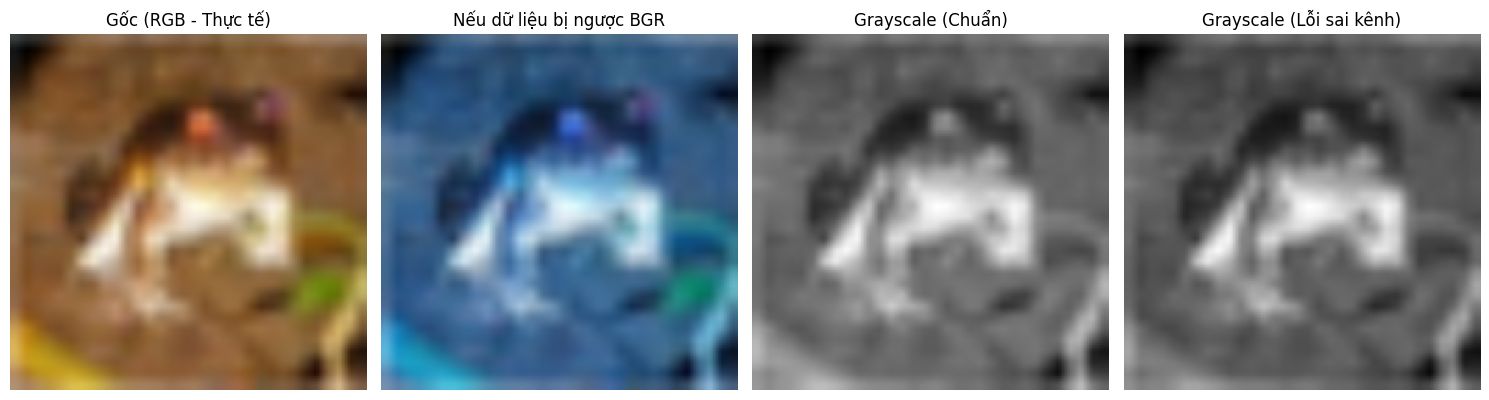

-> Xác nhận: CIFAR-10 gốc được lưu dưới dạng RGB. Việc dùng cv2.COLOR_RGB2GRAY là chính xác!

Đang chuyển đổi tập Huấn luyện (Train) sang ảnh xám...
  > Hoàn thành 50000 ảnh trong 1.83 giây.

Đang chuyển đổi tập Kiểm tra (Test) sang ảnh xám...
  > Hoàn thành 10000 ảnh trong 0.45 giây.

Kích thước ảnh xám sau chuyển đổi:
- Train: (50000, 128, 128)
- Test : (10000, 128, 128)


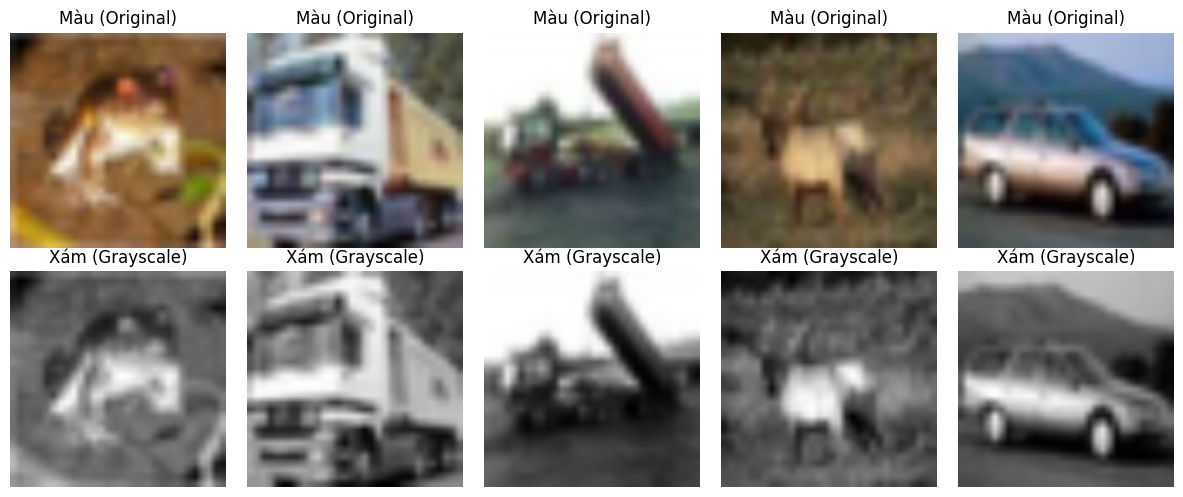

In [ ]:
# --- BƯỚC 2: CHUYỂN ĐỔI ẢNH XÁM (GRAYSCALE CONVERSION) ---

import cv2
import time
from concurrent.futures import ThreadPoolExecutor

# --- 1. KIỂM CHỨNG KHÔNG GIAN MÀU (RGB vs BGR) ---
plt.figure(figsize=(15, 4))

# Ảnh hiển thị mặc định (Giả định RGB)
plt.subplot(1, 4, 1)
plt.imshow(train_images_resized[0]) 
plt.title("Gốc (RGB - Thực tế)")
plt.axis('off')

# Nếu dữ liệu thực sự là BGR, khi đảo kênh nó sẽ ra màu rất kỳ lạ
plt.subplot(1, 4, 2)
plt.imshow(train_images_resized[0][:, :, ::-1]) 
plt.title("Nếu dữ liệu bị ngược BGR")
plt.axis('off')

# Grayscale chuẩn từ RGB
plt.subplot(1, 4, 3)
gray_correct = cv2.cvtColor(train_images_resized[0], cv2.COLOR_RGB2GRAY)
plt.imshow(gray_correct, cmap='gray')
plt.title("Grayscale (Chuẩn)")
plt.axis('off')

# Grayscale sai nếu nhầm lẫn không gian màu
plt.subplot(1, 4, 4)
gray_wrong = cv2.cvtColor(train_images_resized[0][:, :, ::-1], cv2.COLOR_RGB2GRAY)
plt.imshow(gray_wrong, cmap='gray')
plt.title("Grayscale (Lỗi sai kênh)")
plt.axis('off')

plt.tight_layout()
plt.show()
print("-> Xác nhận: CIFAR-10 gốc được lưu dưới dạng RGB. Việc dùng cv2.COLOR_RGB2GRAY là chính xác!\n")

# --- 2. HÀM CHUYỂN ĐỔI ẢNH XÁM (TỐI ƯU ĐA LUỒNG) ---
def convert_single_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def to_grayscale_parallel(images_array):
    start_time = time.time()
    with ThreadPoolExecutor() as executor:
        gray_list = list(executor.map(convert_single_to_gray, images_array))
    print(f"  > Hoàn thành {len(images_array)} ảnh trong {time.time() - start_time:.2f} giây.")
    return np.array(gray_list, dtype=np.uint8)

# --- 3. THỰC HIỆN TRÊN TẬP TRAIN VÀ TEST ---
print("Đang chuyển đổi tập Huấn luyện (Train) sang ảnh xám...")
train_images_gray = to_grayscale_parallel(train_images_resized)

print("\nĐang chuyển đổi tập Kiểm tra (Test) sang ảnh xám...")
test_images_gray = to_grayscale_parallel(test_images_resized)

print(f"\nKích thước ảnh xám sau chuyển đổi:")
print(f"- Train: {train_images_gray.shape}")
print(f"- Test : {test_images_gray.shape}")

# --- 4. HIỂN THỊ SO SÁNH TRỰC QUAN (LẤY 5 ẢNH ĐẦU) ---
plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images_resized[i])
    plt.title('Màu (Original)')
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(train_images_gray[i], cmap='gray')
    plt.title("Xám (Grayscale)")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 2. So sánh khả năng giữ thông tin (Information Retention):

<!-- * **Thông tin được giữ lại:** Cấu trúc hình học (Shapes), các cạnh (Edges), và kết cấu bề mặt (Texture) của đối tượng (ví dụ: hình dáng chiếc xe, cánh máy bay) được bảo toàn nguyên vẹn.
* **Thông tin bị mất:** Toàn bộ thông tin về màu sắc (Chrominance). Ví dụ: sự khác biệt giữa xe màu đỏ và xe màu xanh biến mất; con ếch xanh trên nền lá xanh sẽ mất đi độ tương phản màu sắc, chỉ còn dựa vào độ sáng để phân biệt. -->
Quá trình chuyển đổi từ RGB $(128 \times 128 \times 3)$ sang Grayscale $(128 \times 128 \times 1)$ thực chất là một phép chiếu dữ liệu (projection) gây mất thông tin:

**A. Thông tin được BẢO TOÀN (Preserved Information):**
* **Cấu trúc không gian và Hình học (Spatial Structure & Geometry):**
    * Ảnh xám giữ lại trọn vẹn sự phân bố cường độ sáng (Intensity Distribution). Trong Thị giác máy tính, "hình dạng" của vật thể được định nghĩa bởi các đường bao và ranh giới (Edges/Contours).
    * *Lý do:* Mắt người và các mạng CNN nhận diện vật thể chủ yếu dựa vào sự thay đổi đột ngột của độ sáng (Gradient) chứ không phải màu sắc. Do đó, hình dáng chiếc máy bay (`airplane`) hay khung xe tải (`truck`) vẫn hoàn toàn rõ ràng.
* **Kết cấu bề mặt (Texture Details):** Các chi tiết nhỏ như lông chó/mèo (`dog`/`cat`) hay vân trên cánh chim (`bird`) được thể hiện qua sự thay đổi mức xám cục bộ, do đó vẫn được giữ lại tốt.

**B. Thông tin bị MẤT MÁT (Lost Information):**
* **Đặc trưng quang phổ (Spectral Features/Chrominance):**
    * Toàn bộ thông tin về *Sắc thái (Hue)* và *Độ bão hòa (Saturation)* bị loại bỏ.
    * **Hệ quả:** Mô hình sẽ mất khả năng phân biệt các vật thể có cấu trúc giống hệt nhau nhưng khác màu. *Ví dụ:* Không thể phân biệt quả táo đỏ và quả táo xanh, hay biển báo giao thông "Cấm" (Đỏ) và "Đi" (Xanh) nếu chỉ dựa vào ảnh xám.
* **Độ tương phản đồng mức sáng (Iso-luminant Contrast Loss):**
    * Đây là mất mát nghiêm trọng nhất. Nếu đối tượng (Object) và nền (Background) có màu khác nhau nhưng **độ sáng tương đương nhau**, chúng sẽ bị hòa lẫn vào nhau trong ảnh xám.
    * **Ví dụ trong CIFAR-10:** Một con ếch màu xanh lục (`frog`) ngồi trên lá cây màu xanh lục đậm. Trong ảnh màu, chúng tách biệt rõ. Nhưng khi chuyển sang xám, cả hai đều có mức xám gần bằng nhau, khiến con ếch trở nên khó nhận diện đối với mô hình.

#### 3. Thời điểm chuyển đổi sang ảnh xám có lợi và có hại:
**a. Khi nào NÊN dùng ảnh xám (Beneficial)?**
* **Giảm chi phí tính toán:** Dữ liệu đầu vào giảm đi 3 lần (từ 3 kênh xuống 1 kênh), giúp mô hình huấn luyện nhanh hơn và tốn ít bộ nhớ RAM/GPU hơn.
* **Bài toán dựa trên hình dáng:** Với các bài toán như nhận diện ký tự (OCR), phát hiện biên (Edge Detection), hoặc nhận diện hình khối (Shape recognition), màu sắc thường là thông tin nhiễu (noise). Việc loại bỏ màu sắc giúp mô hình tập trung vào đặc trưng hình học quan trọng nhất.

**b. Khi nào KHÔNG NÊN dùng (Detrimental)?**
* **Bài toán dựa trên màu sắc:** Trong các trường hợp như chẩn đoán bệnh qua da (màu sắc vết thương), phân loại đèn tín hiệu giao thông, hoặc phân loại các loài hoa/chim có hình dáng giống nhau nhưng khác màu. Việc chuyển sang ảnh xám sẽ làm mất đi đặc trưng quyết định (key feature), dẫn đến giảm độ chính xác của mô hình.

## C. NORMALIZATION


#### 1. Chuẩn hóa theo khoảng giá trị (Pixel Normalization)

**Mục tiêu:**
Đưa giá trị pixel từ miền số nguyên $[0, 255]$ về miền số thực $[0, 1]$.

**Lý do thực hiện:**
* Các mô hình Deep Learning thường hoạt động tốt hơn với dữ liệu đầu vào nhỏ (small values).
* Giúp tránh hiện tượng bão hòa (saturation) khi sử dụng các hàm kích hoạt như Sigmoid hay Tanh.
* Giúp quá trình tính toán đạo hàm (gradient) ổn định hơn.

**Phương pháp:**
Nhóm thực hiện **Min-Max Scaling** để đưa dữ liệu về $[0, 1]$:
$$X_{new} = \frac{X - X_{min}}{X_{max} - X_{min}} = \frac{X}{255.0}$$

**Chi tiết thực hiện & Xử lý giới hạn phần cứng (Hardware Constraints Handling):**
* **Vấn đề:** Khi phóng to ảnh lên kích thước $128 \times 128$, tổng dung lượng của 60.000 ảnh (Train + Test) ở dạng `uint8` là khoảng 2.75 GB. Nếu ép kiểu toàn bộ mảng này sang `float32` (4 bytes/pixel) để chia cho 255.0, hệ thống sẽ đòi hỏi khoảng **~11 GB RAM**. Việc này chắc chắn gây ra lỗi tràn bộ nhớ (Memory Error - OOM) trên laptop cá nhân.
* **Giải pháp:** Nhóm áp dụng kỹ thuật **Batch Processing (Xử lý theo lô)** kết hợp với **Memory-Mapped File (`np.memmap`)**. 
    1. Dữ liệu được chia thành các lô nhỏ (`BATCH_SIZE = 5000` ảnh).
    2. Quá trình ép kiểu và chia 255.0 diễn ra độc lập trên từng Batch trong RAM.
    3. Kết quả được xả (flush) và lưu trực tiếp xuống mảng ảo trên ổ cứng vật lý.
* **Đánh giá hiệu quả:** Phương pháp này giúp mức tiêu thụ RAM luôn cố định ở mức cực kỳ thấp (chỉ đủ chứa 5000 ảnh tại một thời điểm), nhưng vẫn hoàn thành việc chuẩn hóa toàn bộ tập dữ liệu gốc mà không bỏ sót bất kỳ tấm ảnh nào.

In [ ]:
# --- C. NORMALIZATION ---
import os
import numpy as np

BATCH_SIZE = 5000

# --- 1. PIXEL NORMALIZATION (MIN-MAX SCALING) VỚI BATCH PROCESSING ---
print("Đang khởi tạo bộ nhớ đệm trên ổ cứng (Memory-Mapped Files)...")

train_scaled_path = os.path.join(extract_folder, 'train_images_scaled.dat')
test_scaled_path = os.path.join(extract_folder, 'test_images_scaled.dat')

train_images_scaled = np.memmap(train_scaled_path, dtype='float32', mode='w+', shape=train_images_resized.shape)
test_images_scaled = np.memmap(test_scaled_path, dtype='float32', mode='w+', shape=test_images_resized.shape)

# --- HÀM XỬ LÝ THEO BATCH ---
def min_max_scale_memmap(source_array, target_memmap, batch_size, name="Data"):
    num_images = source_array.shape[0]
    print(f"Đang thực hiện Min-Max Scaling cho {name} ({num_images} ảnh)...")
    
    for start_idx in range(0, num_images, batch_size):
        end_idx = min(start_idx + batch_size, num_images)
        
        batch_images = source_array[start_idx:end_idx]
        
        batch_scaled = batch_images.astype('float32') / 255.0
        
        target_memmap[start_idx:end_idx] = batch_scaled
        
        target_memmap.flush()
        
        print(f"  > Đã xử lý và lưu xong batch: {start_idx} -> {end_idx}")
        
    print(f"-> Hoàn tất! Kiểm tra {name} đầu tiên: Min={target_memmap[0].min():.2f}, Max={target_memmap[0].max():.2f}\n")

# --- THỰC THI ---
min_max_scale_memmap(train_images_resized, train_images_scaled, BATCH_SIZE, "Tập Train")
min_max_scale_memmap(test_images_resized, test_images_scaled, BATCH_SIZE, "Tập Test")

Đang khởi tạo bộ nhớ đệm trên ổ cứng (Memory-Mapped Files)...
Đang thực hiện Min-Max Scaling cho Tập Train (50000 ảnh)...
  > Đã xử lý và lưu xong batch: 0 -> 5000
  > Đã xử lý và lưu xong batch: 5000 -> 10000
  > Đã xử lý và lưu xong batch: 10000 -> 15000
  > Đã xử lý và lưu xong batch: 15000 -> 20000
  > Đã xử lý và lưu xong batch: 20000 -> 25000
  > Đã xử lý và lưu xong batch: 25000 -> 30000
  > Đã xử lý và lưu xong batch: 30000 -> 35000
  > Đã xử lý và lưu xong batch: 35000 -> 40000
  > Đã xử lý và lưu xong batch: 40000 -> 45000
  > Đã xử lý và lưu xong batch: 45000 -> 50000
-> Hoàn tất! Kiểm tra Tập Train đầu tiên: Min=0.00, Max=1.00

Đang thực hiện Min-Max Scaling cho Tập Test (10000 ảnh)...
  > Đã xử lý và lưu xong batch: 0 -> 5000
  > Đã xử lý và lưu xong batch: 5000 -> 10000
-> Hoàn tất! Kiểm tra Tập Test đầu tiên: Min=0.06, Max=0.99



#### 2. Chuẩn hóa theo phân phối chuẩn (Standardization)

**Mục tiêu:**
Biến đổi dữ liệu sao cho phân phối của nó có **Trung bình (Mean) bằng 0** và **Độ lệch chuẩn (Std) bằng 1**.

**Lý do thực hiện:**
* Đây là kỹ thuật quan trọng giúp dữ liệu "centered" (tâm tại 0), giúp các thuật toán tối ưu (như Gradient Descent) hội tụ nhanh hơn và không bị lệch hướng (zig-zag).
* Đặc biệt hiệu quả với các mạng nơ-ron sâu (Deep Neural Networks) sử dụng hàm kích hoạt ReLU.

**Công thức:**
$$X_{new} = \frac{X - \mu}{\sigma}$$
* $\mu$: Giá trị trung bình của toàn bộ tập dữ liệu.
* $\sigma$: Độ lệch chuẩn của toàn bộ tập dữ liệu.

**Chi tiết thực hiện & Chống rò rỉ dữ liệu (Data Leakage Prevention):**
* **Tính toán thống kê toàn cục (Global Statistics):** Thay vì chỉ tính Mean/Std trên một nhóm nhỏ ảnh (subset), nhóm thực hiện thuật toán "hai bước" (two-pass) trên toàn bộ 50.000 ảnh tập Train bằng Batch Processing để đảm bảo độ chính xác tuyệt đối về mặt thống kê mà không làm tràn bộ nhớ RAM.
* **Nguyên tắc huấn luyện chuẩn mực:** Nhóm chỉ tính toán $\mu$ và $\sigma$ dựa trên **tập Huấn luyện (Train set)**. Sau đó, các giá trị này được dùng để chuẩn hóa cho cả tập Train và **tập Kiểm tra (Test set)**. 
* **Lý do:** Trong thực tế, mô hình không được phép biết trước thông tin thống kê của tập Test. Việc sử dụng tham số của tập Train áp dụng lên tập Test giúp mô phỏng chính xác cách mô hình xử lý dữ liệu mới trong tương lai và tránh hiện tượng rò rỉ thông tin (Data Leakage).

In [ ]:
# --- 2. STANDARDIZATION (Z-SCORE) VỚI BATCH PROCESSING ---

print("Bước 1: Tính toán Global Mean và Global Std của tập TRAIN (Xử lý theo batch)...")

total_pixels_train = train_images_resized.shape[0] * TARGET_SIZE[0] * TARGET_SIZE[1] * 3
global_sum = 0.0
global_sum_sq = 0.0

for start_idx in range(0, train_images_resized.shape[0], BATCH_SIZE):
    end_idx = min(start_idx + BATCH_SIZE, train_images_resized.shape[0])
    
    batch_scaled = train_images_scaled[start_idx:end_idx] 
    
    global_sum += np.sum(batch_scaled)
    global_sum_sq += np.sum(np.square(batch_scaled))

# Tính toán Mean và Std chuẩn xác của 50.000 ảnh Train
train_mean = global_sum / total_pixels_train
train_var = (global_sum_sq / total_pixels_train) - (train_mean ** 2)
train_std = np.sqrt(train_var)

print(f"  > Thống kê tập Train: Mean={train_mean:.4f}, Std={train_std:.4f}")

print("\nBước 2: Thực hiện Standardization và lưu vào ổ cứng...")

train_std_path = os.path.join(extract_folder, 'train_images_std.dat')
test_std_path = os.path.join(extract_folder, 'test_images_std.dat')

train_images_std = np.memmap(train_std_path, dtype='float32', mode='w+', shape=train_images_resized.shape)
test_images_std = np.memmap(test_std_path, dtype='float32', mode='w+', shape=test_images_resized.shape)

# Hàm áp dụng Z-score theo batch
def apply_zscore_memmap(source_memmap, target_memmap, mean, std, batch_size, name="Data"):
    num_images = source_memmap.shape[0]
    print(f"Đang áp dụng Z-score cho {name}...")
    
    for start_idx in range(0, num_images, batch_size):
        end_idx = min(start_idx + batch_size, num_images)
        batch_scaled = source_memmap[start_idx:end_idx]
        
        batch_std = (batch_scaled - mean) / (std + 1e-7)
        
        target_memmap[start_idx:end_idx] = batch_std
        target_memmap.flush()
    print(f"  > Hoàn tất {name}.")

apply_zscore_memmap(train_images_scaled, train_images_std, train_mean, train_std, BATCH_SIZE, "Tập Train")
apply_zscore_memmap(test_images_scaled, test_images_std, train_mean, train_std, BATCH_SIZE, "Tập Test")

print(f"\n-> THÀNH CÔNG! Kiểm tra thống kê sau cùng trên tập Train:")
print(f"   Mean thực tế: {np.mean(train_images_std):.2f} (Kỳ vọng: 0.00)")
print(f"   Std thực tế : {np.std(train_images_std):.2f} (Kỳ vọng: 1.00)")

Bước 1: Tính toán Global Mean và Global Std của tập TRAIN (Xử lý theo batch)...
  > Thống kê tập Train: Mean=0.4730, Std=0.2458

Bước 2: Thực hiện Standardization và lưu vào ổ cứng...
Đang áp dụng Z-score cho Tập Train...
  > Hoàn tất Tập Train.
Đang áp dụng Z-score cho Tập Test...
  > Hoàn tất Tập Test.

-> THÀNH CÔNG! Kiểm tra thống kê sau cùng trên tập Train:
   Mean thực tế: -0.00 (Kỳ vọng: 0.00)
   Std thực tế : 1.00 (Kỳ vọng: 1.00)


#### 3. So sánh và Đánh giá tác động lên phân bố dữ liệu (Comparison & Data Distribution Analysis)

Để đánh giá hiệu quả của các kỹ thuật chuẩn hóa, nhóm thực hiện trực quan hóa biểu đồ tần suất (Histogram) của dữ liệu trước và sau khi xử lý.

**Nhận xét:**
1.  **Ảnh gốc (Original):** Dữ liệu phân bố lệch về phía giá trị dương lớn (0-255), gây khó khăn cho việc khởi tạo trọng số.
2.  **Min-Max Scaling:** Dữ liệu được co lại về $[0, 1]$ nhưng **hình dáng phân bố (shape) không thay đổi**. Phương pháp này giữ nguyên đặc tính thống kê của ảnh gốc.
3.  **Standardization:** Dữ liệu thay đổi hoàn toàn miền giá trị (có cả âm và dương), với tâm nằm tại 0. Đây là dạng phân phối lý tưởng cho việc huấn luyện mô hình AI.

**Kết luận:** Nhóm quyết định sẽ sử dụng **Standardization** cho các bước tiếp theo vì tính ưu việt của nó trong việc hỗ trợ hội tụ mô hình.

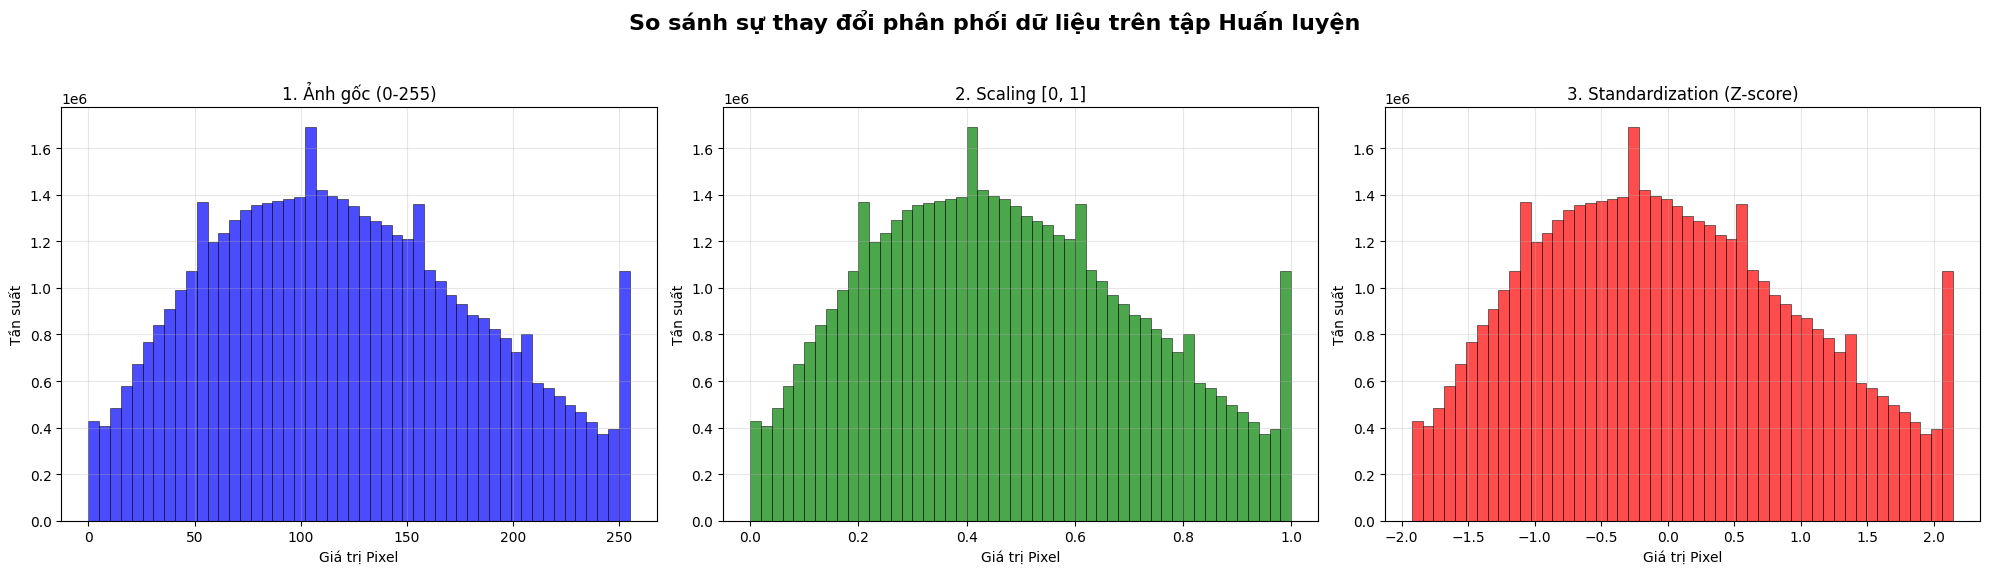

In [ ]:
# --- 3. VẼ BIỂU ĐỒ SO SÁNH PHÂN PHỐI (HISTOGRAM) ---

def plot_distribution(data, title, color, ax):
    sample_size = 1000
    sample_data = np.array(data[:sample_size]).flatten()
    
    ax.hist(sample_data, bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Giá trị Pixel')
    ax.set_ylabel('Tần suất')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_distribution(train_images_resized, "1. Ảnh gốc (0-255)", 'blue', axes[0])
plot_distribution(train_images_scaled, "2. Scaling [0, 1]", 'green', axes[1])
plot_distribution(train_images_std, "3. Standardization (Z-score)", 'red', axes[2])

plt.suptitle("So sánh sự thay đổi phân phối dữ liệu trên tập Huấn luyện", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## D. EDGE DETECTION (OPTIONAL BONUS)

### 1. Phát hiện biên (Edge Detection)

**Mục tiêu:**
Trích xuất các đặc trưng hình học (geometric features) quan trọng của đối tượng bằng cách xác định các đường biên (edges) — nơi có sự thay đổi đột ngột về cường độ sáng. Việc này giúp loại bỏ các thông tin dư thừa không cần thiết (màu sắc rực rỡ, ánh sáng nền phức tạp) và tập trung vào "khung xương" cấu trúc cốt lõi của vật thể.

**So sánh các phương pháp thực nghiệm:**
Để chọn ra thuật toán tối ưu nhất cho bộ dữ liệu CIFAR-10, nhóm đã tiến hành khảo sát và đối chứng 3 toán tử phổ biến:
* **Toán tử Sobel:** Sử dụng đạo hàm bậc nhất để tìm cường độ gradient. 
    * *Đánh giá:* Ưu điểm là tính toán nhanh, nhưng biên thu được thường bị dày và nhạy cảm với các biến đổi nhiễu nhỏ trong ảnh.
* **Toán tử Laplacian:** Sử dụng đạo hàm bậc hai để tìm các điểm cực trị (zero-crossing). 
    * *Đánh giá:* Do tính chất của đạo hàm bậc hai, phương pháp này **cực kỳ nhạy cảm với nhiễu** (noise). Nếu ảnh không được làm mịn kỹ, kết quả thường xuất hiện nhiều đốm trắng rác (artifacts) gây nhiễu cho mô hình.
* **Thuật toán Canny (Lựa chọn tối ưu):** Đây là một quy trình đa giai đoạn phức tạp hơn, được thiết kế để khắc phục nhược điểm của các toán tử trên. Canny cho ra đường biên mảnh, sạch và có tính liên tục cao nhất.



**Quy trình xử lý của thuật toán Canny:**
Nhóm triển khai thuật toán Canny thông qua 4 bước tiêu chuẩn để đảm bảo độ chính xác:

1.  **Khử nhiễu (Noise Reduction):** Sử dụng bộ lọc Gaussian $(5 \times 5)$ để làm mượt ảnh, giúp loại bỏ các chi tiết nhiễu hạt trước khi thực hiện tính toán đạo hàm.
2.  **Tính Gradient (Sobel Filtering):** Xác định cường độ và hướng thay đổi độ sáng tại từng pixel.
3.  **Làm mảnh biên (Non-maximum Suppression):** Duy trì các điểm ảnh có giá trị gradient lớn nhất theo hướng đạo hàm, giúp ép độ dày của đường biên về mức chuẩn **1 pixel**.
4.  **Phân ngưỡng trễ (Hysteresis Thresholding):** Đây là cơ chế thông minh nhất của Canny, sử dụng hai ngưỡng `100` (ngưỡng thấp) và `200` (ngưỡng cao):
    * **Biên mạnh (> 200):** Được xác định chắc chắn là biên và giữ lại.
    * **Biên yếu (100 - 200):** Chỉ được giữ lại nếu nó kết nối trực tiếp với một "biên mạnh". Điều này giúp loại bỏ nhiễu hiệu quả mà vẫn duy trì được sự liên tục của các đường viền vật thể.

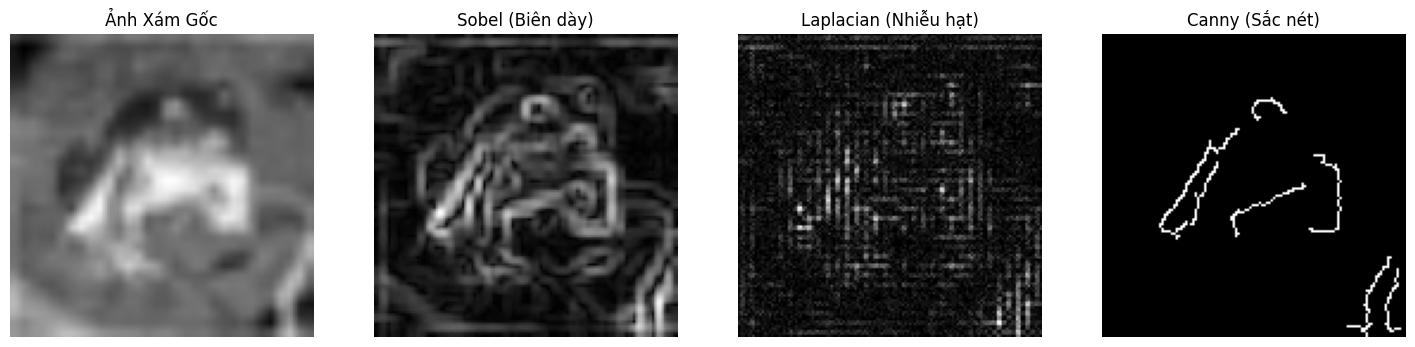

Đang xử lý biên cho 60.000 ảnh...


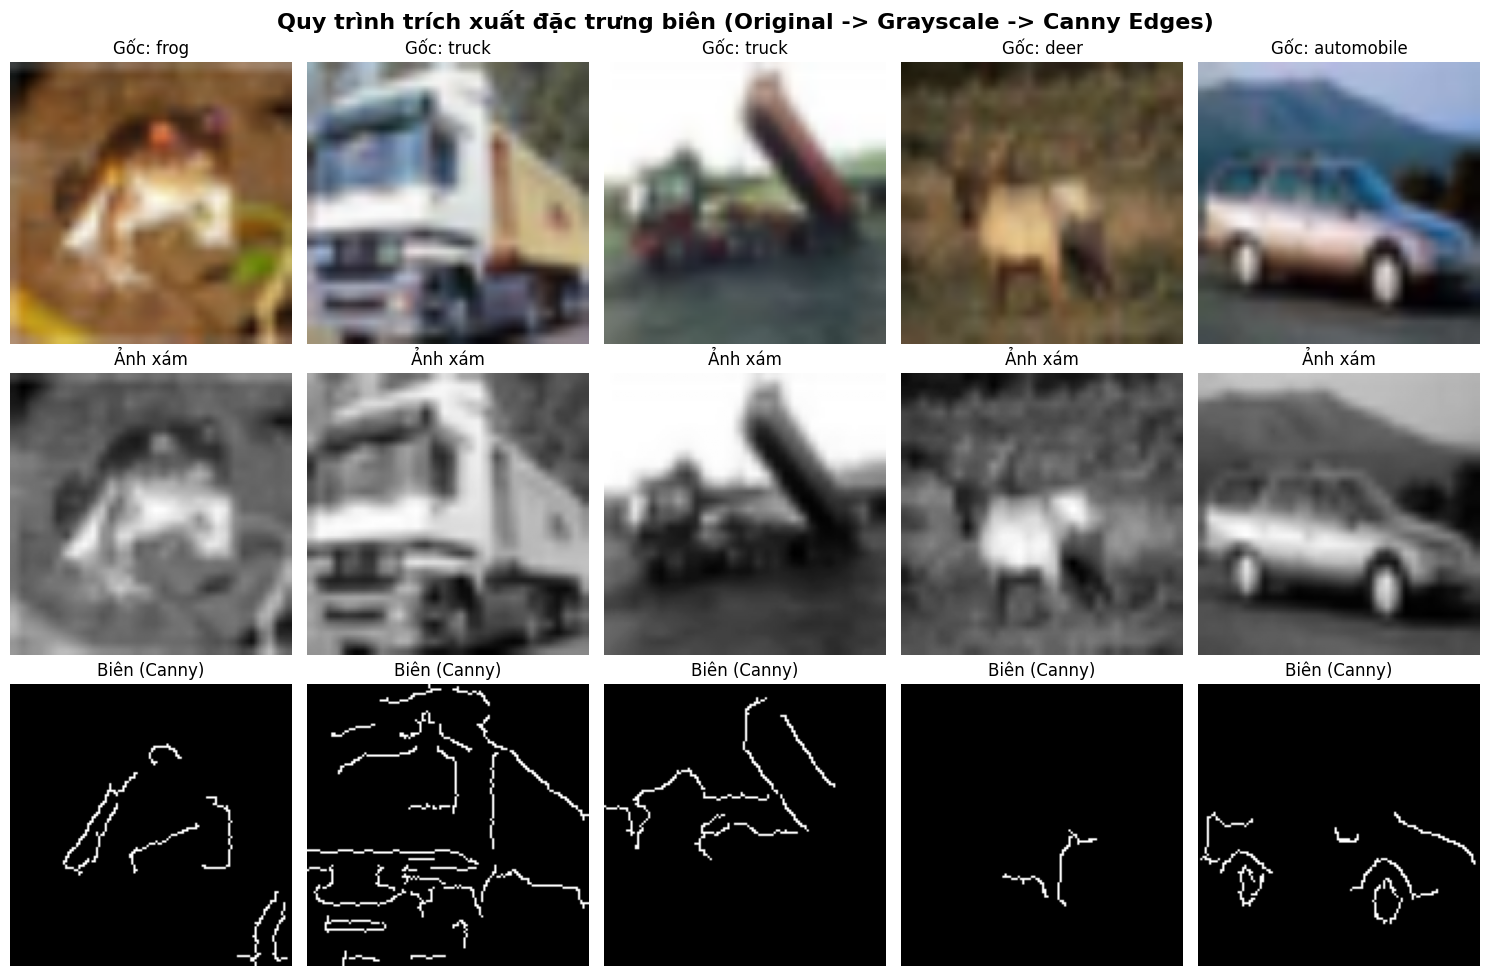

In [ ]:
# --- D. EDGE DETECTION (CANNY) ---
import cv2
import time
from concurrent.futures import ThreadPoolExecutor

sample_img = train_images_gray[0]

# A. Phương pháp Sobel 
sobelx = cv2.Sobel(sample_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(sample_img, cv2.CV_64F, 0, 1, ksize=3)
edges_sobel = np.uint8(np.absolute(np.sqrt(sobelx**2 + sobely**2)))

# B. Phương pháp Laplacian
edges_laplacian = cv2.Laplacian(sample_img, cv2.CV_64F)
edges_laplacian = np.uint8(np.absolute(edges_laplacian))

# C. Phương pháp Canny
edges_canny = cv2.Canny(sample_img, 100, 200)

# Trực quan hóa
plt.figure(figsize=(18, 5))
methods = [sample_img, edges_sobel, edges_laplacian, edges_canny]
titles = ['Ảnh Xám Gốc', 'Sobel (Biên dày)', 'Laplacian (Nhiễu hạt)', 'Canny (Sắc nét)']

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(methods[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# --- 2. XỬ LÝ ---
def apply_canny_single(img):
    return cv2.Canny(img, 100, 200)

def extract_edges_parallel(images_array):
    with ThreadPoolExecutor() as executor:
        edges_list = list(executor.map(apply_canny_single, images_array))
    return np.array(edges_list, dtype=np.uint8)

print("Đang xử lý biên cho 60.000 ảnh...")
train_images_edges = extract_edges_parallel(train_images_gray)
test_images_edges = extract_edges_parallel(test_images_gray)

# --- 3. HIỂN THỊ KẾT QUẢ 3 TẦNG (GỐC - XÁM - BIÊN) ---
plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(3, 5, i+1)
    plt.imshow(train_images_resized[i])
    plt.title(f"Gốc: {label_names[raw_train_labels[i]]}")
    plt.axis('off')
    
    plt.subplot(3, 5, i+6)
    plt.imshow(train_images_gray[i], cmap='gray')
    plt.title("Ảnh xám")
    plt.axis('off')

    plt.subplot(3, 5, i+11)
    plt.imshow(train_images_edges[i], cmap='gray')
    plt.title("Biên (Canny)")
    plt.axis('off')

plt.suptitle("Quy trình trích xuất đặc trưng biên (Original -> Grayscale -> Canny Edges)", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 2. Thảo luận ý nghĩa (Significance Analysis)

Việc trích xuất biên mang lại những lợi ích chiến lược cho quá trình huấn luyện mô hình Machine Learning sau này:

* **Tính bất biến với cường độ sáng và màu sắc (Invariance to Illumination & Color):** Ảnh biên giúp mô hình đạt được tính **Robust** (bền vững). Một chiếc "ô tô" có thể màu đỏ hoặc xanh, xuất hiện lúc nắng hay trong bóng râm, nhưng cấu trúc hình học (khung xe, bánh xe) là bất biến. Canny giúp mô hình không bị "đánh lừa" bởi các yếu tố ngoại cảnh này.
* **Dữ liệu thưa và giảm nhiễu (Data Sparsity):** Ảnh biên là một ma trận cực kỳ thưa với phần lớn giá trị bằng 0. Điều này giúp các bộ lọc tích chập (Convolutional Filters) dễ dàng tập trung vào các vị trí quan trọng, giảm thiểu chi phí tính toán và tránh hiện tượng quá khớp (**Overfitting**) vào các chi tiết màu sắc rác.
* **Trích xuất đặc trưng bậc thấp (Low-level Feature Extraction):** Trong mạng Neural (CNN), các tầng đầu tiên thường học các nét vẽ và đường biên. Việc chủ động trích xuất biên giúp "mồi" dữ liệu, giúp mô hình nhanh chóng nhận diện được các khối hình dạng phức tạp ở các tầng sâu hơn.
* **Phân biệt cấu trúc (Structural Discriminability):** Làm nổi bật sự khác biệt về "khung xương" giữa các lớp. Ví dụ: sự khác biệt giữa cấu trúc cơ khí (cánh thẳng của máy bay) và cấu trúc hữu cơ (đường cong của con chim) trở nên rõ rệt hơn khi loại bỏ lớp màu sắc.